written on colab

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold
from sklearn.metrics import accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score, balanced_accuracy_score, recall_score, precision_score
from sklearn.base import clone

## **Setup**

In [3]:
# a - load real dataset
data_spam = pd.read_csv("Spam.csv")
data_spam.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [10]:
X_spam = data_spam.drop(columns="spam")
y_spam = data_spam["spam"]

In [12]:
def sigma(x):
  return 1 / (1 + np.exp(-x))

In [13]:
# b - artificial data set
# params
n = 1000      # sample size
k = 20        # number of irrelevant variables
p = 5 + k     # 5 relevant + k irrelevant variables
b = 0.5       # signal strength
alpha = 1     # class imbalance

# X matrix
X = np.zeros((n, p))
for j in np.arange(0, p, 1):
  X[:, j] = np.random.normal(loc=0, scale=1, size=n)

beta_true = np.zeros(p)
beta_true[0:5] = b

s = alpha + np.dot(X, beta_true)
prob_true = sigma(s)

y = np.zeros(n)
for i in np.arange(0, n, 1):
  y[i] = np.random.binomial(1, prob_true[i], size=1)[0]

#### **How will increasing α influence the imbalance in the dataset?**

The parameter alpha acts as an intercept. When alpha increases, the value of the linear predictor alpha + beta^T * X becomes larger on average, the logistic function returns higher probabilities, which increases the likelihood of Y=1. Therefore:
- larger alpha - more observations from class 1
- smaller alpha - fewer observations from class 1

#### **For a given α, what is the expected class proportion P(Y = 1)? How does it determine the class imbalance?**

Class imbalance is determined by how far P(Y=1) is from 0.5:
- P(Y=1) = about 0.5 -> balanced dataset
- P(Y=1) close to 0 or close to 1 -> imbalanced dataset.

#### **Consider two classification models: logistic regression and classification tree. Which model do you expect to be more stable under repeated sampling?**

I would expect logistic regression to be more stable under repeated sampling than a classification tree. Logistic regression is a parametric model that estimates a rather small number of coefficients and changes gently when the training data change slightly.<br>

Classification trees tend to have high variance and small changes in the training data set can lead to different splits resulting in different tree structure and different prediction.

# **Tasks**

## **Task 1**

In [14]:
models = {
    "Logistic regression": LogisticRegression(max_iter=1000),
    "Classification tree": DecisionTreeClassifier(random_state=42),
}

### **Refitting**

In [19]:
# train and test the model on the same data
for name, base_model in models.items():
  model = clone(base_model)
  model.fit(X, y)
  y_pred = model.predict(X)
  err = np.mean(y != y_pred)

  print(name)
  print("Refitting error:", err)
  print()

Logistic regression
Refitting error: 0.236

Classification tree
Refitting error: 0.0



### **10-fold cross-validation**

#### **implementation from scratch**

In [20]:
# mix indexes
n = X.shape[0]
indices = np.random.permutation(n)

# divide into 10 folds
folds = np.array_split(indices, 10)

# loop through folds
errors = []

for i in range(10):
  test_idx = folds[i]
  train_idx = np.concatenate([folds[j] for j in range(10) if j != i])

  model = LogisticRegression(max_iter=1000)
  model.fit(X[train_idx], y[train_idx])

  y_pred = model.predict(X[test_idx])

  err = np.mean(y_pred != y[test_idx])
  errors.append(err)

cv_error = np.mean(errors)
print(cv_error)

0.259


#### **with built in functions**

In [21]:
for name, base_model in models.items():
  model = clone(base_model)
  scores = cross_val_score(model, X, y, cv=10, scoring="accuracy")
  err = np.mean(1 - scores)

  print(name)
  print("10-fold cv error:", err)
  print()

Logistic regression
10-fold cv error: 0.25200000000000006

Classification tree
10-fold cv error: 0.357



### **Bootstrap method**

#### **implementation from scratch**

In [22]:
# probke treningowa losujemy ze zwracaniem (z powtorzeniami) i testujemy na obiektach ktore nie weszly do probki
B = 100
n = X.shape[0]

for name, base_model in models.items():
    errors = []

    for b in range(B):
        train_idx = np.random.choice(n, size=n, replace=True)
        test_idx = np.setdiff1d(np.arange(n), train_idx)

        if len(test_idx) == 0:
            continue

        model = clone(base_model)
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])

        err = np.mean(y_pred != y[test_idx])
        errors.append(err)

    print(name)
    print("Bootstrap error:", np.mean(errors))
    print()


Logistic regression
Bootstrap error: 0.26287584360820004

Classification tree
Bootstrap error: 0.37331465710615064



### **Bootstrap 0.632.**

In [23]:
# err_632 = 0.368 * err_refit + 0.632 * err_bootstrap

B = 100
n = X.shape[0]

for name, base_model in models.items():
    # refitting error
    model_refit = clone(base_model)
    model_refit.fit(X, y)
    y_pred_refit = model_refit.predict(X)
    err_refit = np.mean(y_pred_refit != y)

    # bootstrap OOB error
    boot_errors = []

    for b in range(B):
        train_idx = np.random.choice(n, size=n, replace=True)
        test_idx = np.setdiff1d(np.arange(n), train_idx)

        if len(test_idx) == 0:
            continue

        model = clone(base_model)
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])

        err = np.mean(y_pred != y[test_idx])
        boot_errors.append(err)

    err_boot = np.mean(boot_errors)

    # bootstrap 0.632
    err_632 = 0.368 * err_refit + 0.632 * err_boot

    print(name)
    print("Refitting error:", err_refit)
    print("Bootstrap error:", err_boot)
    print("Bootstrap 0.632 error:", err_632)
    print()

Logistic regression
Refitting error: 0.236
Bootstrap error: 0.2627688088550571
Bootstrap 0.632 error: 0.2529178871963961

Classification tree
Refitting error: 0.0
Bootstrap error: 0.3714994543503223
Bootstrap 0.632 error: 0.2347876551494037



### **All together**

In [24]:
B = 100
n = X.shape[0]

results = []

for name, base_model in models.items():

    # refitting
    model = clone(base_model)
    model.fit(X, y)
    y_pred = model.predict(X)
    err_refit = np.mean(y_pred != y)

    # 10-fold CV
    scores = cross_val_score(base_model, X, y, cv=10, scoring="accuracy")
    err_cv = np.mean(1 - scores)

    # bootstrap OOB
    boot_errors = []

    for b in range(B):
        train_idx = np.random.choice(n, size=n, replace=True)
        test_idx = np.setdiff1d(np.arange(n), train_idx)

        if len(test_idx) == 0:
            continue

        model = clone(base_model)
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])

        err = np.mean(y_pred != y[test_idx])
        boot_errors.append(err)

    err_boot = np.mean(boot_errors)

    # bootstrap 0.632
    err_632 = 0.368 * err_refit + 0.632 * err_boot

    results.append({
        "Model": name,
        "Refitting": err_refit,
        "10-fold CV": err_cv,
        "Bootstrap": err_boot,
        "Bootstrap 0.632": err_632
    })

results_df = pd.DataFrame(results)
results_df

,Model,Refitting,10-fold CV,Bootstrap,Bootstrap 0.632
0,Logistic regression,0.236,0.252,0.261266,0.251968
1,Classification tree,0.000,0.357,0.371531,0.234807


## **Task 2**

In [37]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.5,
    train_size=0.5,
    random_state=42,
)

In [39]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [40]:
probs = model.predict_proba(X_val)[:,1]

#### **ROC curve**

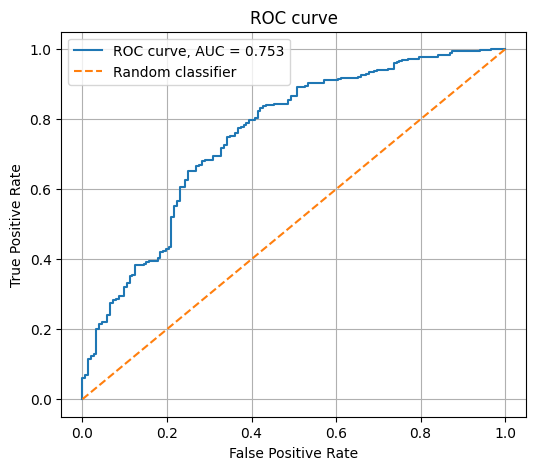

In [41]:
fpr, tpr, thresholds_roc = roc_curve(y_val, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid()
plt.show()

ROC curve shows the trade-off between True Positive Rate and False Positive Rate for different classification thresholds.<br>

A larger AUC means better separation between the two classes.

#### **precision-recall curve**

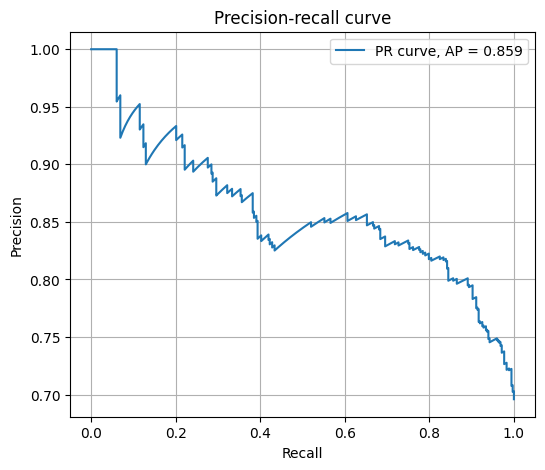

In [43]:
precision, recall, thresholds_pr = precision_recall_curve(y_val, probs)
ap = average_precision_score(y_val, probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve, AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curve")
plt.legend()
plt.grid()
plt.show()

The precision-recall curve shows the trade-off between precision and recall for different classification thresholds.<br>

It is especially useful when the classes are imbalanced.

### **Loop over all parameters**

In [47]:
def generate_data(n=1000, k=20, p=5+k, b=0.5, alpha=1, random_state=42):
  X = np.zeros((n, p))
  for j in np.arange(0, p, 1):
    X[:, j] = np.random.normal(loc=0, scale=1, size=n)

  beta_true = np.zeros(p)
  beta_true[0:5] = b

  s = alpha + np.dot(X, beta_true)
  prob_true = sigma(s)

  y = np.zeros(n)
  for i in np.arange(0, n, 1):
    y[i] = np.random.binomial(1, prob_true[i], size=1)[0]

  return X, y

In [46]:
n_values = [100, 1000]
b_values = [0.5, 1]
k_values = [5, 50]
alpha_values = [0, 2]

In [48]:
results = []

for n in n_values:
    for b in b_values:
        for k in k_values:
            for alpha in alpha_values:

                X, y = generate_data(n=n, b=b, k=k, alpha=alpha, random_state=42)

                X_train, X_val, y_train, y_val = train_test_split(
                    X, y,
                    test_size=0.5,
                    random_state=42,
                )

                model = LogisticRegression(max_iter=1000)
                model.fit(X_train, y_train)

                probs = model.predict_proba(X_val)[:, 1]

                fpr, tpr, _ = roc_curve(y_val, probs)
                roc_auc = auc(fpr, tpr)

                precision, recall, _ = precision_recall_curve(y_val, probs)
                ap = average_precision_score(y_val, probs)

                class_1_prop = np.mean(y)

                results.append({
                    "n": n,
                    "b": b,
                    "k": k,
                    "alpha": alpha,
                    "class_1_prop": class_1_prop,
                    "ROC AUC": roc_auc,
                    "Average Precision": ap
                })

In [49]:
results_df = pd.DataFrame(results)
results_df

,n,b,k,alpha,class_1_prop,ROC AUC,Average Precision
0,100,0.5,5,0,0.420,0.668309,0.588236
1,100,0.5,5,2,0.880,0.773810,0.943264
2,100,0.5,50,0,0.540,0.778325,0.864482
3,100,0.5,50,2,0.830,0.772358,0.947443
4,100,1.0,5,0,0.510,0.730769,0.728727
5,100,1.0,5,2,0.790,0.632500,0.876093
6,100,1.0,50,0,0.520,0.701923,0.719332
7,100,1.0,50,2,0.740,0.660714,0.860333
8,1000,0.5,5,0,0.515,0.771045,0.769066
9,1000,0.5,5,2,0.820,0.690687,0.911397


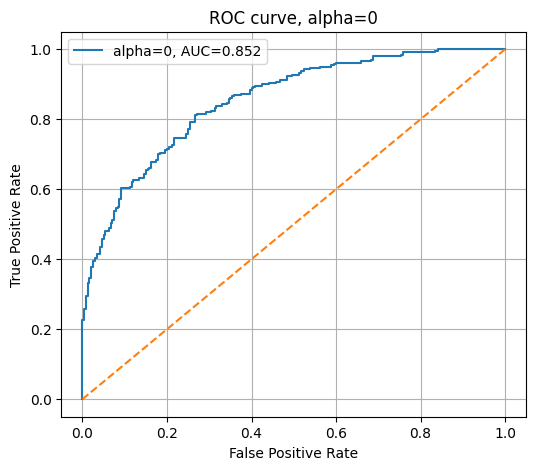

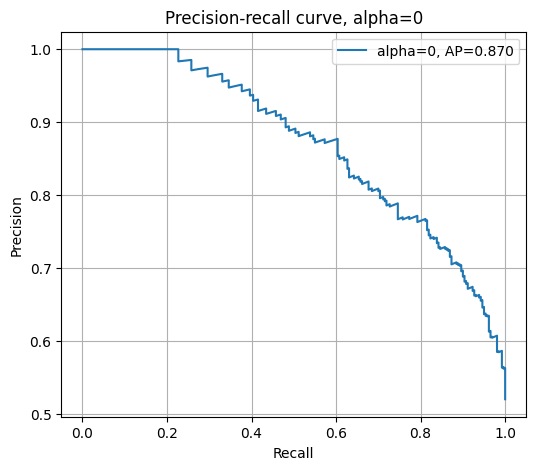

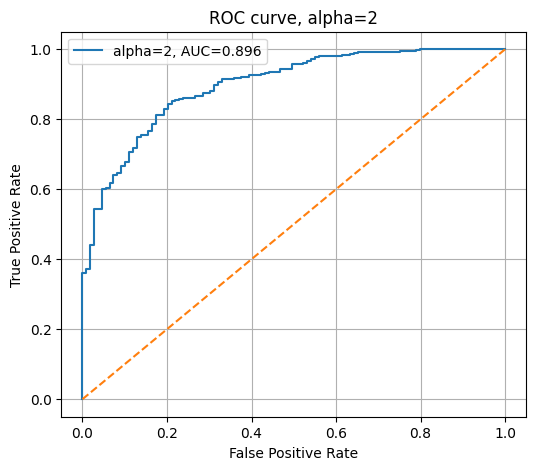

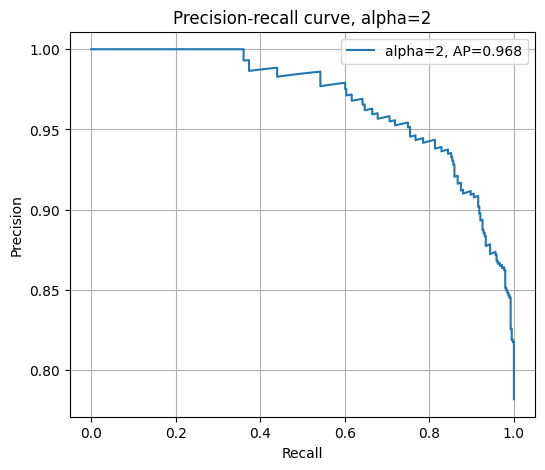

In [50]:
for alpha in alpha_values:

    X, y = generate_data(n=1000, b=1, k=20, alpha=alpha, random_state=42)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.5,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"alpha={alpha}, AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve, alpha={alpha}")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"alpha={alpha}, AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-recall curve, alpha={alpha}")
    plt.legend()
    plt.grid()
    plt.show()

For alpha = 2, the precision-recall curve is more informative than the ROC curve, because the dataset is more imbalanced.

## **Task 3**

In [60]:
# Split data into training (50%) and validation (50%) sets. Fit the logistic regression model using training

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5)

model = LogisticRegression()
model.fit(X_train, y_train)

prob2 = model.predict_proba(X_val)[:, 1]

In [65]:
# calculate accuracy and balanced accuracy on validation data using classification rule P(yi = 1|xi) >t, where t is a threshold.

t_seq = np.linspace(0.05, 0.95, 200)

acc = np.zeros(200)
bacc = np.zeros(200)
rec = np.zeros(200)
prec = np.zeros(200)

i = 0
for t in t_seq:
    y_val_pred = np.where(prob2 > t, 1, 0)

    acc[i] = accuracy_score(y_val, y_val_pred)
    bacc[i] = balanced_accuracy_score(y_val, y_val_pred)
    rec[i] = recall_score(y_val, y_val_pred)
    prec[i] = precision_score(y_val, y_val_pred)

    i += 1

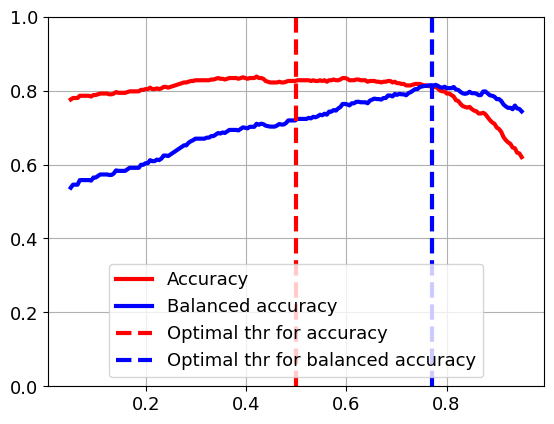

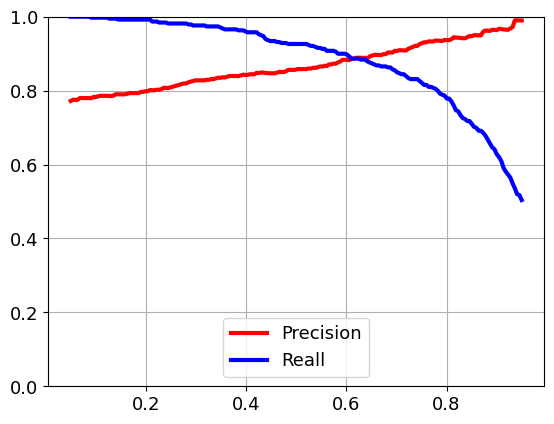

In [66]:
# Draw plots showing how accuracy and balanced accuracy depend on t∈[0,1]. On the accuracy plot, draw a line at t= 0.5; while for the
# balanced accuracy, draw a line at t=(1/ntrain) Sum yi.

plt.style.use("default")
plt.rcParams.update({"font.size": 13})
plt.plot(t_seq, acc, color="r", label="Accuracy", linewidth=3)
plt.plot(t_seq, bacc, color="b", label="Balanced accuracy", linewidth=3)
plt.axvline(x=0.5, color="r", label="Optimal thr for accuracy", linestyle="dashed", linewidth=3)
plt.axvline(x=np.mean(y_train), color="b", label="Optimal thr for balanced accuracy", linestyle="dashed", linewidth=3)
plt.legend(loc="lower center")
plt.ylim(0, 1)
plt.grid(which="both")
plt.show()

plt.style.use("default")
plt.rcParams.update({"font.size": 13})
plt.plot(t_seq, prec, color="r", label="Precision", linewidth=3)
plt.plot(t_seq, rec, color="b", label="Reall", linewidth=3)
plt.legend(loc="lower center")
plt.ylim(0, 1)
plt.grid(which="both")
plt.show()

#### **Why the accuracy / balanced accuracy tends to have a maximum around those points?**

The threshold t = 0.5 is the natural decision boundary for logistic regression. If the estimated probability exceeds 0.5, class 1 is more likely than class 0. Therefore, when false positive and false negative costs are equal, the classification accuracy often reaches its maximum near t = 0.5.<br>

Balanced accuracy gives equal importance to both classes. In imbalanced datasets, a threshold close to the observed proportion of positive examples often provides a better balance between sensitivity and specificity. Therefore, balanced accuracy frequently reaches its maximum near the training-set prevalence of class 1.

#### **How would the optimal threshold change if false positives and false negatives had different costs?**

If false negatives are more costly than false positives, the threshold should be decreased in order to detect more positive cases. This increases recall at the expense of more false positives.

If false positives are more costly, the threshold should be increased so that the classifier predicts the positive class only when it is sufficiently confident. This reduces false positives but may increase the number of false negatives.